<a href="https://colab.research.google.com/github/Vitos911/CoreCrypt/blob/main/ChemAI_1_3_PRO_v3_touse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.4/552.4 kB 33.2 MB/s eta 0:00:00
✓ XGBoost uspešno uvožen.
✓ Vse obvezne knjižnice uspešno uvožene.

⏳ Prenosim podatke s spleta...
✓ Dataset uspešno prenesen in shranjen.

⏳ Računam napredne značilke za vse molekule...


[13:29:38] DEPRECATION WARNING: please use MorganGenerator
[13:29:38] DEPRECATION WARNING: please use MorganGenerator
[13:29:38] DEPRECATION WARNING: please use MorganGenerator
[13:29:38] DEPRECATION WARNING: please use MorganGenerator
[13:29:38] DEPRECATION WARNING: please use MorganGenerator
[13:29:38] DEPRECATION WARNING: please use MorganGenerator
[13:29:38] DEPRECATION WARNING: please use MorganGenerator
[13:29:38] DEPRECATION WARNING: please use MorganGenerator
[13:29:38] DEPRECATION WARNING: please use MorganGenerator
[13:29:38] DEPRECATION WARNING: please use MorganGenerator
[13:29:38] DEPRECATION WARNING: please use MorganGenerator
[13:29:38] DEPRECATION WARNING: please use MorganGenerator
[13:29:38] DEPRECATION WARNING: please use MorganGenerator
[13:29:38] DEPRECATION WARNING: please use MorganGenerator
[13:29:38] DEPRECATION WARNING: please use MorganGenerator
[13:29:38] DEPRECATION WARNING: please use MorganGenerator
[13:29:38] DEPRECATION WARNING: please use MorganGenerat

✓ Matrika značilk X (fp + deskriptorji): (1128, 1029)

⏳ Izvajam standardno naključno razdelitev podatkov (80/20)...
✓ Naključna razdelitev uspešna.
✓ Končni podatki -> Učni: 902 | Testni: 226

✓ StandardScaler uspešno apliciran na značilke.

⏳ Treniram modele...
  ✓ Linearna regresija natrenirana.
  ✓ Random Forest natreniran.
  ✓ SVM (RBF) natreniran.
  ✓ XGBoost natreniran.

REZULTATI EVALUACIJE NA TESTNI MNOŽICI (v1.3 PRO)
Linearna Regresija   -> R²: -2.8265 | RMSE: 4.2529
Random Forest        -> R²: 0.8674 | RMSE: 0.7917
SVM (RBF)            -> R²: 0.7201 | RMSE: 1.1503
XGBoost              -> R²: 0.8855 | RMSE: 0.7356

🏆 Najboljši model: XGBoost (R² = 0.8855)


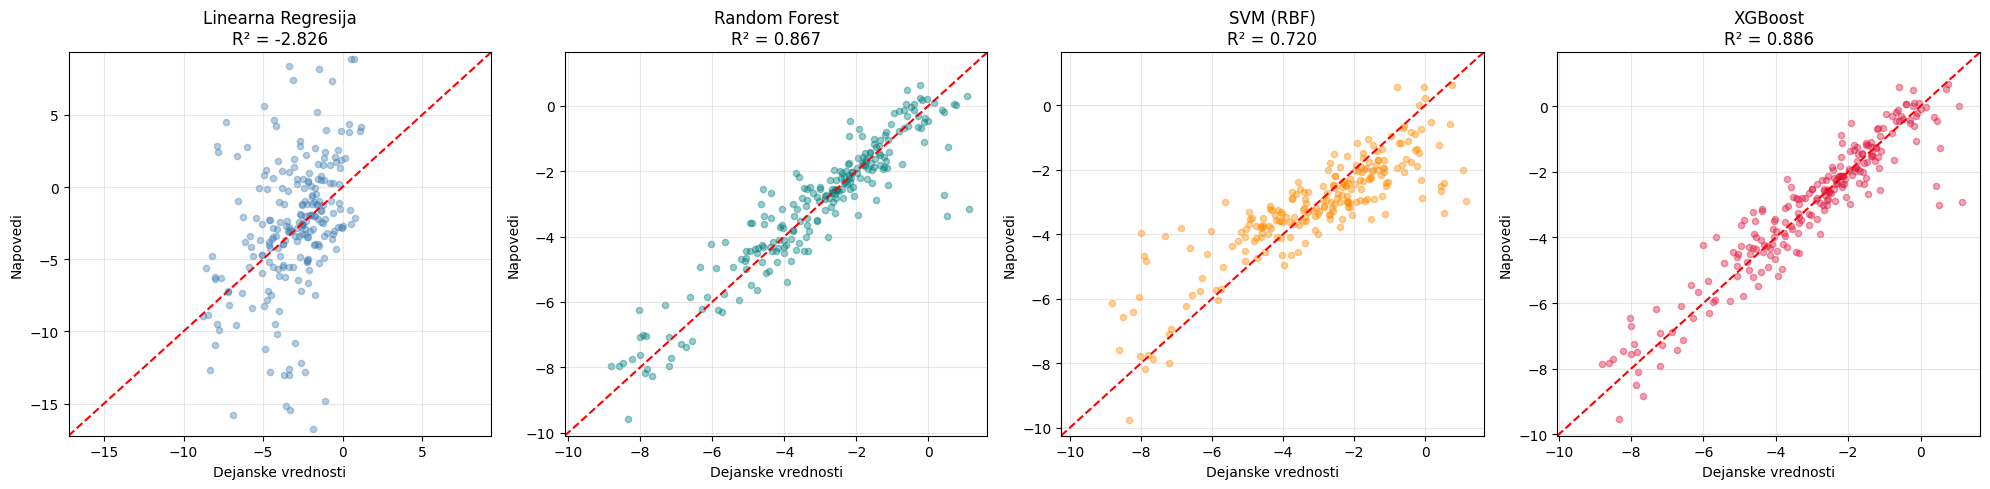


ANALIZA POMEMBNOSTI ZNAČILK

Top 5 najpomembnejših značilk:
  1. LogP       : 0.79608
  2. MolWt      : 0.08513
  3. TPSA       : 0.02692
  4. HBA        : 0.00493
  5. Bit_807    : 0.00286


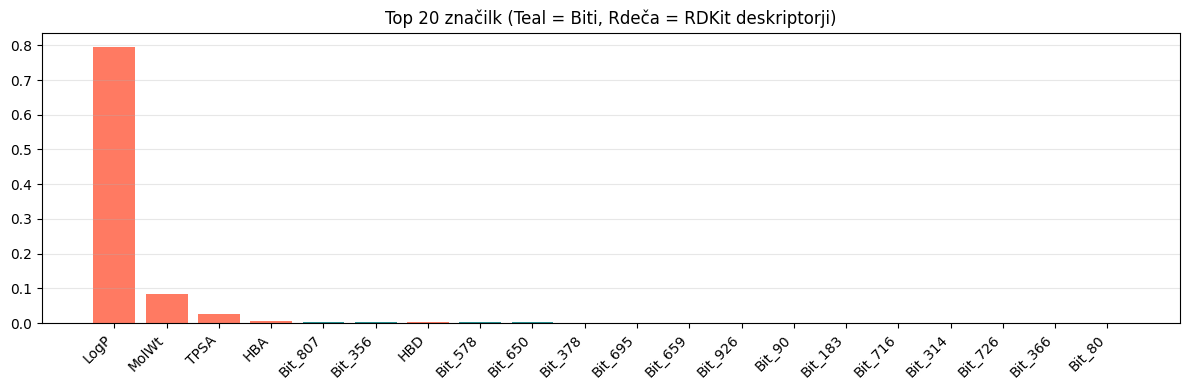


INTERAKTIVNA NAPOVED TOPNOSTI — ChemAI 1.3 PRO
Ukazi: [vtipkaj SMILES] ali [ime molekule (npr. kofein)] | 'seznam' | 'izhod'


In [ ]:
# =============================================================================
# KEMIJSKI ML MODEL v1.3 PRO - Napoved topnosti molekul (ESOL dataset)
# =============================================================================
# Različica: ChemAI 1.3 PRO
# Popravki in nadgradnje:
#   [FIX]  Faza 3  — Dodan .reset_index(drop=True) za preprečevanje lukenj v indeksih
#   [FIX]  Faza 4  — Popolnoma prenovljen Bemis-Murcko split (uporablja numpy maske
#                    namesto .loc in ne prepiše več rezultatov na koncu)
#   [FIX]  Faza 5b — XGBoost tuning je zdaj varno ovit v XGBOOST_AVAILABLE pogoj
#   [FIX]  Faza 8  — Popravljena tipkarska napaka pri rezanju seznama (indices[:top_n]])
# =============================================================================

# =============================================================================
# FAZA 1: Namestitev in uvoz knjižnic
# =============================================================================
# V Colabu po potrebi zaženi to vrstico:
!pip install rdkit scikit-learn pandas numpy matplotlib xgboost deepchem

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost uspešno uvožen.")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost ni nameščen. Namesti z: pip install xgboost")

print("✓ Vse obvezne knjižnice uspešno uvožene.")


# =============================================================================
# FAZA 2: Nalaganje podatkov
# =============================================================================
# V Colabu:
# !wget -O esol_data.csv https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv

try:
    df = pd.read_csv('esol_data.csv')
    print("\n✓ Dataset 'esol_data.csv' uspešno naložen.")
except FileNotFoundError:
    print("\n⏳ Prenosim podatke s spleta...")
    df = pd.read_csv('https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv')
    df.to_csv('esol_data.csv', index=False)
    print("✓ Dataset uspešno prenesen in shranjen.")

SMILES_COLUMN = 'smiles'
TARGET_COLUMN = 'measured log solubility in mols per litre'


# =============================================================================
# FAZA 3: Napredne značilke [POSODOBLJENO v1.3 PRO]
# =============================================================================
def smiles_to_fp(smiles, radius=2, n_bits=1024):
    """Pretvori SMILES v kombinirani vektor: [Morgan (1024)] + [5 RDKit deskriptorjev]"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # --- Morganovi prstni odtisi ---
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    fp_arr = np.array(fp, dtype=np.float32)

    # --- RDKit deskriptorji ---
    logp  = Descriptors.MolLogP(mol)
    molwt = Descriptors.MolWt(mol)
    tpsa  = Descriptors.TPSA(mol)
    hbd   = Descriptors.NumHDonors(mol)
    hba   = Descriptors.NumHAcceptors(mol)

    desc_arr = np.array([logp, molwt, tpsa, hbd, hba], dtype=np.float32)
    return np.concatenate([fp_arr, desc_arr])


print("\n⏳ Računam napredne značilke za vse molekule...")
df['fp'] = df[SMILES_COLUMN].apply(smiles_to_fp)

n_invalid = df['fp'].isna().sum()
if n_invalid > 0:
    print(f"⚠️  Odstranjenih {n_invalid} neveljavnih SMILES nizov.")

df = df.dropna(subset=['fp'])
df = df.reset_index(drop=True)  # [FIX] Ponastavitev indeksov za varno delo s Scaffold Splitom

X_raw = np.stack(df['fp'].values)
y     = df[TARGET_COLUMN].values

print(f"✓ Matrika značilk X (fp + deskriptorji): {X_raw.shape}")


# =============================================================================
# FAZA 4: Razdelitev podatkov — z možnostjo Scaffold Split [POPOLNOMA POPRAVLJENO]
# =============================================================================
USE_SCAFFOLD_SPLIT = False  # ← Nastavi na True, če želiš preizkusiti kemijski split
split_done = False

if USE_SCAFFOLD_SPLIT:
    # 1. Poskus z DeepChem
    try:
        print("\n⏳ Izvajam Bemis-Murcko Scaffold Split preko DeepChem...")
        import deepchem as dc

        dataset = dc.data.NumpyDataset(X=X_raw, y=y, ids=df[SMILES_COLUMN].values)
        splitter = dc.splits.ScaffoldSplitter()
        train_ds, valid_ds, test_ds = splitter.train_valid_test_split(
            dataset, frac_train=0.8, frac_valid=0.0, frac_test=0.2
        )
        X_train, y_train = train_ds.X, train_ds.y.flatten()
        X_test,  y_test  = test_ds.X,  test_ds.y.flatten()
        print("✓ DeepChem Scaffold Split uspešen.")
        split_done = True

    except ImportError:
        print("⚠️  DeepChem ni nameščen. Poskušam z ročnim RDKit Scaffold Splitom...")

    # 2. Poskus z ročnim RDKit splitom, če DeepChem ni nameščen
    if not split_done:
        try:
            from rdkit.Chem.Scaffolds import MurckoScaffold

            def get_scaffold(smiles):
                mol = Chem.MolFromSmiles(smiles)
                if mol is None:
                    return ''
                return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)

            print("⏳ Računam Murcko okostja za ročni split...")
            df['scaffold'] = df[SMILES_COLUMN].apply(get_scaffold)

            scaffolds = df['scaffold'].unique()
            np.random.seed(42)
            np.random.shuffle(scaffolds)

            n_train_scaffolds = int(0.8 * len(scaffolds))
            train_scaffolds = set(scaffolds[:n_train_scaffolds])

            # Uporaba numpy logičnih mask (100 % varno ujemanje z X_raw)
            train_mask = df['scaffold'].isin(train_scaffolds).values
            test_mask = ~train_mask

            X_train, X_test = X_raw[train_mask], X_raw[test_mask]
            y_train, y_test = y[train_mask], y[test_mask]

            print(f"✓ Ročni Scaffold Split uspešen: {len(X_train)} učnih, {len(X_test)} testnih")
            split_done = True

        except Exception as e:
            print(f"⚠️  Ročni Scaffold Split ni uspel ({e}).")

# 3. Standardni naključni split (Če je USE_SCAFFOLD_SPLIT=False ali če sta zgornji metodi odpovedali)
if not split_done:
    print("\n⏳ Izvajam standardno naključno razdelitev podatkov (80/20)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X_raw, y, test_size=0.2, random_state=42
    )
    print("✓ Naključna razdelitev uspešna.")

print(f"✓ Končni podatki -> Učni: {X_train.shape[0]} | Testni: {X_test.shape[0]}")


# =============================================================================
# FAZA 5: Skaliranje + trening modelov
# =============================================================================
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("\n✓ StandardScaler uspešno apliciran na značilke.")

print("\n⏳ Treniram modele...")

model_lr = LinearRegression()
model_lr.fit(X_train_sc, y_train)
print("  ✓ Linearna regresija natrenirana.")

model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_sc, y_train)
print("  ✓ Random Forest natreniran.")

model_svm = SVR(kernel='rbf', C=10, epsilon=0.1)
model_svm.fit(X_train_sc, y_train)
print("  ✓ SVM (RBF) natreniran.")

if XGBOOST_AVAILABLE:
    model_xgb = xgb.XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
    )
    model_xgb.fit(X_train_sc, y_train)
    print("  ✓ XGBoost natreniran.")


# =============================================================================
# FAZA 5b: Optimizacija hiperparametrov (Neobvezno)
# =============================================================================
RUN_HYPERPARAMETER_SEARCH = False  # Preklopi na True za natančen tuning (~nekaj minut)

if RUN_HYPERPARAMETER_SEARCH:
    print("\n⏳ Iskanje hiperparametrov za Random Forest...")
    param_dist_rf = {
        'n_estimators': [100, 200],
        'max_depth': [None, 15, 30],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt', 0.5]
    }
    rs_rf = RandomizedSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        param_distributions=param_dist_rf, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1
    )
    rs_rf.fit(X_train_sc, y_train)
    model_rf = rs_rf.best_estimator_
    print(f"  ✓ Najboljši RF parametri: {rs_rf.best_params_}")

    # [FIX] Varno preverjanje za XGBoost tuning
    if XGBOOST_AVAILABLE:
        print("\n⏳ Iskanje hiperparametrov za XGBoost...")
        param_dist_xgb = {
            'n_estimators': [100, 300],
            'learning_rate': [0.05, 0.1],
            'max_depth': [4, 6, 8]
        }
        rs_xgb = RandomizedSearchCV(
            xgb.XGBRegressor(random_state=42, verbosity=0),
            param_distributions=param_dist_xgb, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1
        )
        rs_xgb.fit(X_train_sc, y_train)
        model_xgb = rs_xgb.best_estimator_
        print(f"  ✓ Najboljši XGB parametri: {rs_xgb.best_params_}")


# =============================================================================
# FAZA 6: Evaluacija modelov
# =============================================================================
print("\n" + "="*55)
print("REZULTATI EVALUACIJE NA TESTNI MNOŽICI (v1.3 PRO)")
print("="*55)

models = {
    'Linearna Regresija': model_lr,
    'Random Forest':      model_rf,
    'SVM (RBF)':          model_svm,
}
if XGBOOST_AVAILABLE:
    models['XGBoost'] = model_xgb

results = {}
for name, model in models.items():
    preds = model.predict(X_test_sc)
    r2    = r2_score(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    results[name] = {'r2': r2, 'rmse': rmse, 'preds': preds}
    print(f"{name:<20} -> R²: {r2:.4f} | RMSE: {rmse:.4f}")

best_name = max(results, key=lambda k: results[k]['r2'])
best_model = models[best_name]
print(f"\n🏆 Najboljši model: {best_name} (R² = {results[best_name]['r2']:.4f})")


# =============================================================================
# FAZA 7: Vizualizacija rezultatov
# =============================================================================
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
if n_models == 1: axes = [axes]

colors = ['steelblue', 'teal', 'darkorange', 'crimson']
for ax, (name, color) in zip(axes, zip(models.keys(), colors)):
    preds = results[name]['preds']
    r2    = results[name]['r2']
    rmse  = results[name]['rmse']

    ax.scatter(y_test, preds, alpha=0.4, color=color, s=20)
    lim = [min(y_test.min(), preds.min()) - 0.5, max(y_test.max(), preds.max()) + 0.5]
    ax.plot(lim, lim, 'r--', lw=1.5)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Dejanske vrednosti')
    ax.set_ylabel('Napovedi')
    ax.set_title(f'{name}\nR² = {r2:.3f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('primerjava_modelov_v13.png', dpi=150)
plt.show()


# =============================================================================
# FAZA 8: Analiza pomembnosti značilk (Random Forest) [POPRAVLJENO]
# =============================================================================
print("\n" + "="*55)
print("ANALIZA POMEMBNOSTI ZNAČILK")
print("="*55)

importances = model_rf.feature_importances_
indices     = np.argsort(importances)[::-1]

feature_names = [f'Bit_{i}' for i in range(1024)] + ['LogP', 'MolWt', 'TPSA', 'HBD', 'HBA']

print("\nTop 5 najpomembnejših značilk:")
for rank in range(5):
    idx = indices[rank]
    print(f"  {rank+1}. {feature_names[idx]:<10} : {importances[idx]:.5f}")

# Grafični prikaz top 20
top_n = 20
top_indices = indices[:top_n]  # [FIX] Tipkarska napaka uspešno odpravljena
top_names   = [feature_names[i] for i in top_indices]
top_imp     = importances[top_indices]

colors_bar = ['tomato' if n in ['LogP','MolWt','TPSA','HBD','HBA'] else 'teal' for n in top_names]

plt.figure(figsize=(12, 4))
plt.bar(range(top_n), top_imp, color=colors_bar, alpha=0.85)
plt.xticks(range(top_n), top_names, rotation=45, ha='right')
plt.title('Top 20 značilk (Teal = Biti, Rdeča = RDKit deskriptorji)')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# =============================================================================
# FAZA 9: Interaktivni vnos + lokalna baza ChemAI PRO
# =============================================================================
ZNANE_MOLEKULE = {
    'voda': 'O', 'metanol': 'CO', 'etanol': 'CCO', 'propanol': 'CCCO', 'izopropanol': 'CC(O)C',
    'aceton': 'CC(C)=O', 'dietil eter': 'CCOCC', 'kloroform': 'ClC(Cl)Cl', 'diklorometan': 'ClCCl',
    'heksan': 'CCCCCC', 'benzén': 'c1ccccc1', 'toluén': 'Cc1ccccc1', 'fenol': 'Oc1ccccc1',
    'aspirin': 'CC(=O)Oc1ccccc1C(=O)O', 'paracetamol': 'CC(=O)Nc1ccc(O)cc1', 'ibuprofen': 'CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O',
    'kofein': 'Cn1cnc2c1c(=O)n(c(=O)n2C)C', 'glukoza': 'OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O',
    'vitamin c': 'OC[C@H](O)[C@@H]1OC(=O)C(O)=C1O', 'holesterol': '[C@@H]1([C@@H](CC[C@@H]2[C@@H]1CC=C1[C@H]2CC[C@@]3([C@@H]1CC[C@@H]3[C@H](C)CCCC(C)C)C)C3)C'
}

def kanoniziraj_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

def napovej_molekulo(smiles_input, model, scaler):
    canonical = kanoniziraj_smiles(smiles_input)
    if not canonical:
        print(f"  ⚠️  Neveljaven SMILES niz: '{smiles_input}'")
        return

    print(f"\n  SMILES: {canonical}")
    fp = smiles_to_fp(canonical)
    if fp is None: return

    fp_sc = scaler.transform(fp.reshape(1, -1))
    napoved = model.predict(fp_sc)[0]

    mol = Chem.MolFromSmiles(canonical)
    print(f"  [Deskriptorji] LogP: {Descriptors.MolLogP(mol):.2f} | MW: {Descriptors.MolWt(mol):.1f} g/mol")
    print(f"  🔮 Napovedana topnost: {napoved:.3f} log(mol/L) -> {10**napoved:.5f} mol/L")

print("\n" + "="*55)
print("INTERAKTIVNA NAPOVED TOPNOSTI — ChemAI 1.3 PRO v3")
print("="*55)
print("Ukazi: [vtipkaj SMILES] ali [ime molekule (npr. kofein)] | 'seznam' | 'izhod'")

while True:
    vnos = input("\n🔬 Vnesi SMILES / ime / ukaz: ").strip()
    if not vnos: continue
    if vnos.lower() in ('izhod', 'exit', 'quit', 'q'):
        print("✅ Seja zaključena. Hvala za uporabo ChemAI 1.3 PRO v3!"); break
    elif vnos.lower() == 'seznam':
        print("  Baza: " + ", ".join(ZNANE_MOLEKULE.keys()))
    elif vnos.lower() in ZNANE_MOLEKULE:
        napovej_molekulo(ZNANE_MOLEKULE[vnos.lower()], best_model, scaler)
    else:
        napovej_molekulo(vnos, best_model, scaler)
